<a href="https://colab.research.google.com/github/arthireddy14/Machine_Learning/blob/main/dbscan_mall_customers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [3]:
df=pd.read_csv('Mall_Customers.csv')
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [6]:
x=df[['Annual Income (k$)','Spending Score (1-100)']]

In [7]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled= scaler.fit_transform(x[['Annual Income (k$)','Spending Score (1-100)']])

In [8]:
dbscan=DBSCAN(eps=0.3,min_samples=5)
clusters=dbscan.fit_predict(x_scaled)

In [9]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters=5)
labels = model.fit_predict(x[['Annual Income (k$)', 'Spending Score (1-100)']])


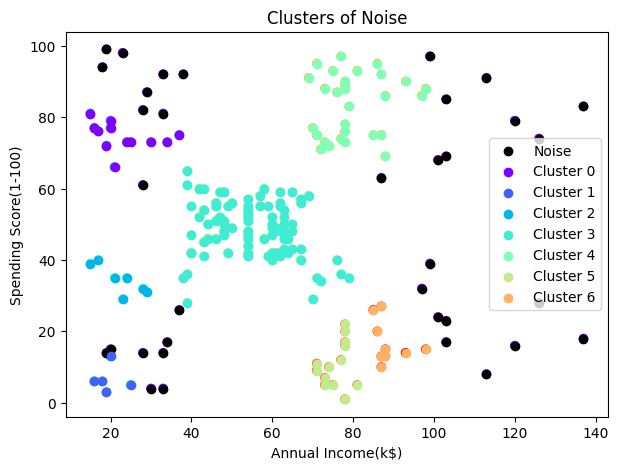

In [10]:
plt.figure(figsize=(7,5))
plt.scatter(x['Annual Income (k$)'],x['Spending Score (1-100)'],c=clusters,cmap='rainbow')
unique_labels = np.unique(clusters)

for label in unique_labels:

    if label == -1:
        # Noise points → Black
        color = 'black'
        label_name = 'Noise'
    else:
        # Normal clusters → Use colormap
        color = plt.cm.rainbow(label / len(unique_labels))
        label_name = f'Cluster {label}'

    plt.scatter(
        x[clusters == label]['Annual Income (k$)'],
        x[clusters == label]['Spending Score (1-100)'],
        # x.iloc()
        c=[color],
        label=label_name
    )
plt.xlabel('Annual Income(k$)')
plt.ylabel('Spending Score(1-100)')
plt.title('Clusters of Noise')
# plt.colorbar()
plt.legend()
plt.show()

In [11]:
from sklearn.metrics import silhouette_score
score=silhouette_score(x_scaled,clusters)
print("Silhouette score ",score)

Silhouette score  0.31614121976731185


In [14]:
eps_values=[0.2,0.3,0.5]

for eps in eps_values:
  print(f"\n Evaluating DBSCAN using eps={eps}")
  dbscan=DBSCAN(eps=eps,min_samples=5)
  labels=dbscan.fit_predict(x_scaled)
  # Number of clusters(ignore noise label -1)
  unique_labels=set(labels)
  n_clusters=len(unique_labels)-(1 if -1 in unique_labels else 0)
  # No. of noise points
  n_noise=list(labels).count(-1)
  noise_ratio=n_noise/len(labels)
  print(f"Number of clusters :{n_clusters}")
  print(f"Number of noise points: ",round(noise_ratio,3))
  # Silhoutte score(only if valid)
  if n_clusters>0:
    score=silhouette_score(x_scaled,labels)
    print("Silhouette score: ",round(score,3))
  else:
    print("Silhouette Score: Not valid (<=1 cluster)")


 Evaluating DBSCAN using eps=0.2
Number of clusters :7
Number of noise points:  0.385
Silhouette score:  0.141

 Evaluating DBSCAN using eps=0.3
Number of clusters :7
Number of noise points:  0.175
Silhouette score:  0.316

 Evaluating DBSCAN using eps=0.5
Number of clusters :2
Number of noise points:  0.04
Silhouette score:  0.35
